Compute mean connectivity from HCP7T dataset

In [1]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from glob import glob

In [2]:
tian_scale = 'S2'

lut_fpath = os.path.join('/Users/dsj3886/data_local/derivatives/',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet',
                         f'atlas-custom_subcort-tian{tian_scale}_cort-aud-vis-carpet_lut.tsv')

region_list = list(pd.read_csv(lut_fpath, sep='\t', header=None).iloc[:,1])

In [3]:
region_list

['aPUT-lh',
 'pPUT-lh',
 'aCAU-lh',
 'pCAU-lh',
 'aPUT-rh',
 'pPUT-rh',
 'aCAU-rh',
 'pCAU-rh',
 'L-HG',
 'L-PP',
 'L-PT',
 'L-STGa',
 'L-STGp',
 'R-HG',
 'R-PP',
 'R-PT',
 'R-STGa',
 'R-STGp',
 'L-LOCsup',
 'L-LOCinf',
 'L-IntraCalc',
 'L-TempOccFus',
 'L-OccFus',
 'L-SupraCalc',
 'L-OccPole',
 'R-LOCsup',
 'R-LOCinf',
 'R-IntraCalc',
 'R-TempOccFus',
 'R-OccFus',
 'R-SupraCalc',
 'R-OccPole']

In [4]:
data_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                        'HCP_7T_diffusion/msmt_csd_nthreads-1/')

## Read in participant connectivity matrices

In [5]:
print(data_dir + 
      '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv')

/Users/dsj3886/data_local/derivatives/HCP_7T_diffusion/msmt_csd_nthreads-1//*/connectome_streamlines_alg-iFOD2_nsl-10mil/atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv


In [6]:
conn_files = sorted(glob(data_dir + 
                         '/*/connectome_streamlines_alg-iFOD2_nsl-10mil/'+
                         f'atlas-custom_subcort-tian{tian_scale}_cort-carpet_sift2/'+
                         'streamlines_alg-iFOD2_nsl-10mil_connectome_sift2.csv'))

# derive participant IDs directly from conn_files (preserves same order)
participants_with_files = sorted(list({os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(p)))) for p in conn_files}))


In [7]:
print(len(conn_files))

96


In [8]:
test_df = pd.read_csv(conn_files[0], header=None)
print(test_df)
print(len(test_df))


             0            1            2            3            4   \
0   8268.074209  3171.177498  2156.096386   828.728846    80.337416   
1   3171.177498  3677.825174   304.758787  1126.495766    67.175016   
2   2156.096386   304.758787  8997.764935  1554.796652    69.710324   
3    828.728846  1126.495766  1554.796652  3014.341623    30.107019   
4     80.337416    67.175016    69.710324    30.107019  9985.398348   
5    105.360801   189.179635    15.751270    97.746538  3218.237984   
6     24.730155    10.277543    31.992937    21.574194  3155.990691   
7     27.268470    21.221287    19.345882    51.452262   237.809434   
8     65.834432  3104.246460     4.357843    19.704495     0.280541   
9   1039.054971  4790.470911    32.089380    63.850731    17.240047   
10   285.033913  1161.845649    29.873710    63.258076     0.000000   
11    17.673466   303.012608     1.401305     5.224105     0.000000   
12    85.995214   168.422050     7.799678    23.021013     0.000000   
13    

In [9]:
# loop through each subject's connectivity matrix and clean up the formatting
num_regions = len(test_df) # number of regions of interest in the HCP analysis
num_subjects = len(conn_files)
connmats = np.zeros((num_subjects, num_regions, num_regions))
slcounts = np.zeros((num_regions, num_subjects))
list_df = []
for sx, matrix_fpath in enumerate(conn_files):

    sub_df = pd.read_csv(matrix_fpath, header=None)
    list_df.append(sub_df)
    
    connmats[sx,:,:] = sub_df.to_numpy()
    
    slcounts[:,sx] = sub_df.to_numpy().sum(axis=0) # sub_df.iloc[:,0]

In [10]:
np.shape(connmats)

(96, 32, 32)

In [11]:
# check the streamline count matrix (region x subject)
slcounts

array([[1.76549240e+04, 1.23438669e+04, 1.62320679e+04, ...,
        1.22546618e+00, 1.40319727e+00, 1.58966587e+00],
       [2.87630393e+04, 2.45096872e+04, 3.39282210e+04, ...,
        2.50707697e+00, 2.90795179e+00, 3.48593396e+00],
       [1.33349388e+04, 3.81352467e+03, 6.33383022e+03, ...,
        1.33146244e+00, 2.39993079e+00, 1.42717371e+00],
       ...,
       [1.36109862e+05, 1.31451117e+05, 8.74709999e+04, ...,
        5.92345496e+00, 6.03157280e+00, 7.41906025e+00],
       [1.46672655e+04, 2.05444162e+04, 2.79056571e+04, ...,
        1.24304271e+00, 2.91927144e+00, 1.65354611e+00],
       [1.77609962e+05, 1.23138864e+05, 1.28152539e+05, ...,
        2.47380257e+00, 2.44083286e+00, 2.95087768e+00]])

In [12]:
slcounts[0,:]

array([1.76549240e+04, 1.23438669e+04, 1.62320679e+04, 1.34106256e+04,
       1.10093724e+04, 9.13794657e+03, 1.34044247e+04, 1.10465835e+04,
       1.32685602e+04, 1.44412994e+04, 1.42371272e+04, 1.81507005e+04,
       1.07186078e+04, 1.79893258e+04, 9.34883685e+03, 1.53932314e+04,
       1.43629094e+04, 4.57719069e+03, 1.04952311e+04, 1.37204802e+04,
       1.00731076e+04, 1.76689577e+04, 1.18400797e+04, 1.36310386e+04,
       1.25054617e+04, 2.11918492e+04, 1.59622642e+04, 1.44644173e+04,
       1.16016733e+04, 1.50002579e+04, 9.86614231e+03, 1.11063599e+04,
       1.15845928e+04, 1.21713971e+04, 1.01572864e+04, 1.36965965e+04,
       1.30373079e+04, 8.93040127e+03, 1.29972390e+04, 1.59158732e+04,
       1.09201880e+04, 1.16059353e+04, 1.01205020e+04, 8.63078626e+03,
       1.57881634e+04, 7.93875283e+03, 1.20085217e+04, 1.06939969e+04,
       1.42974071e+04, 1.48577429e+04, 7.28405413e+03, 1.28721134e+04,
       1.38320985e+04, 1.61681470e+04, 8.44753356e+03, 1.08991994e+04,
      

## Compute mean streamline count per ROI

In [13]:
# compute the mean streamline count per IC subdivision
mean_slcount = slcounts.mean(axis=1)
print(mean_slcount)
print(mean_slcount.shape)

[ 10010.19541179  19958.99009649   6302.19596174   4330.70264329
  12278.77500188  22121.2629355    6786.24167321   5601.02329044
  24476.14633827  31896.51286142  41810.68840283  23737.78181133
  34342.55773441  23742.23605477  26954.10324392  37654.0310592
  14443.2960992   44088.86050703 169163.48228434  98903.83345973
  47016.49948266  51576.39513469      0.          17494.55343904
 143691.23173848 146777.39451772 101886.18581357  47034.70941246
  48479.33676951  91810.91322037  14122.83275843 103808.03849364]
(32,)


In [14]:
mean_connmat = connmats.mean(axis=0)

print(mean_connmat)
print(mean_connmat.shape)

[[3.70227369e+03 1.84679427e+03 1.11716878e+03 ... 6.53841791e+02
  8.73160468e-02 3.20936932e-02]
 [1.84679427e+03 2.78852869e+03 1.34964481e+02 ... 7.47194139e+02
  3.08878061e+00 2.23684636e+00]
 [1.11716878e+03 1.34964481e+02 3.61993364e+03 ... 2.43052844e+01
  1.79274670e-01 0.00000000e+00]
 ...
 [6.53841791e+02 7.47194139e+02 2.43052844e+01 ... 4.06699901e+04
  2.57260659e+01 1.76251438e+01]
 [8.73160468e-02 3.08878061e+00 1.79274670e-01 ... 2.57260659e+01
  1.58922887e+03 2.13582083e+03]
 [3.20936932e-02 2.23684636e+00 0.00000000e+00 ... 1.76251438e+01
  2.13582083e+03 5.67210284e+04]]
(32, 32)


In [15]:

# add ROI names to df
mean_df = pd.DataFrame(mean_connmat, columns=region_list)
mean_df.insert(0, 'seed', region_list)
mean_df.insert(0, 'mean_slcount', mean_slcount)


In [16]:
mean_df

,mean_slcount,seed,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,10010.195412,aPUT-lh,3702.273694,1846.794266,1117.168781,246.927898,18.191753,15.659749,21.510202,14.716531,...,0.0,1.955425e+01,164.824712,0.016623,0.031199,0.911657,3.629341,653.841791,0.087316,0.032094
1,19958.990096,pPUT-lh,1846.794266,2788.528689,134.964481,631.083091,13.448051,38.793448,8.064336,20.014177,...,0.0,5.212059e+01,2270.108342,4.491149,0.003099,4.317355,3.541874,747.194139,3.088781,2.236846
2,6302.195962,aCAU-lh,1117.168781,134.964481,3619.933636,1162.811123,18.459896,9.426221,67.924784,26.744789,...,0.0,4.816195e+00,0.005728,0.164820,0.007468,1.229591,0.767029,24.305284,0.179275,0.000000
3,4330.702643,pCAU-lh,246.927898,631.083091,1162.811123,1796.634528,15.057295,33.364098,34.559116,74.931078,...,0.0,2.325172e+00,7.866558,0.687326,0.030047,0.236909,0.436860,5.621172,0.149256,0.003713
4,12278.775002,aPUT-rh,18.191753,13.448051,18.459896,15.057295,4753.902719,2116.187239,952.287076,185.457195,...,0.0,8.287711e-02,0.002759,719.886640,261.460433,366.397443,114.633539,1.330044,14.306068,282.164136
5,22121.262936,pPUT-rh,15.659749,38.793448,9.426221,33.364098,2116.187239,2866.132482,145.919728,624.967239,...,0.0,7.078323e+00,0.130882,4507.018037,554.028036,343.598410,173.683536,0.165139,30.533496,2611.212035
6,6786.241673,aCAU-rh,21.510202,8.064336,67.924784,34.559116,952.287076,145.919728,3533.587900,1892.008982,...,0.0,4.283014e-02,0.003282,23.815318,3.943603,11.248257,9.619440,0.239871,1.241765,0.099784
7,5601.023290,pCAU-rh,14.716531,20.014177,26.744789,74.931078,185.457195,624.967239,1892.008982,2393.674103,...,0.0,4.701662e-02,0.000000,166.862894,11.318460,3.811314,4.285009,0.004806,0.512458,4.369452
8,24476.146338,L-HG,74.895539,2424.413918,4.038571,4.943051,0.030016,2.734857,0.123248,0.333480,...,0.0,6.622289e+00,19.304178,3.142000,0.003009,0.942764,0.089400,6.934063,0.966946,0.026044
9,31896.512861,L-PP,830.089080,3357.651891,40.249780,68.444583,3.013505,3.943934,1.996793,1.969270,...,0.0,4.917543e+01,1270.753076,0.258218,0.000000,1.982843,0.330810,646.919153,0.988022,1.300375


In [17]:
# save the mean data
out_dir = os.path.join(data_dir, 'group_plots_Apr')
out_fpath = os.path.join(out_dir, 'pd_mean_connectivity_scale-invnodevol.txt')
os.makedirs(out_dir, exist_ok=True)
mean_df.to_csv(out_fpath, sep='\t', index=False)

### Plot distributions

In [18]:
connmats.shape

(96, 32, 32)

<Axes: >

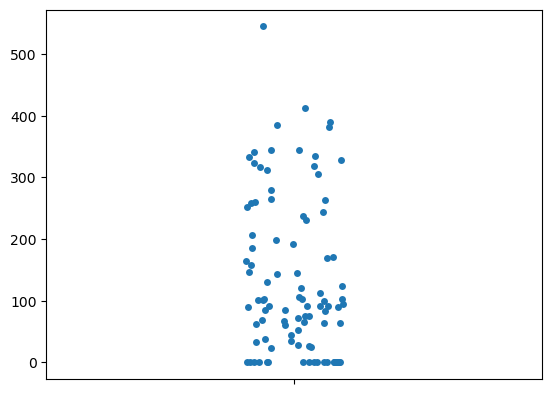

In [19]:
sns.stripplot(connmats[:,1,2])

## Connectivity plots

In [20]:
num_participants = len(connmats)
print('Number of participants:', num_participants)

Number of participants: 96


In [21]:
plot_df = mean_df.iloc[:, 2:]


In [22]:
plot_df

,aPUT-lh,pPUT-lh,aCAU-lh,pCAU-lh,aPUT-rh,pPUT-rh,aCAU-rh,pCAU-rh,L-HG,L-PP,...,L-OccFus,L-SupraCalc,L-OccPole,R-LOCsup,R-LOCinf,R-IntraCalc,R-TempOccFus,R-OccFus,R-SupraCalc,R-OccPole
0,3702.273694,1846.794266,1117.168781,246.927898,18.191753,15.659749,21.510202,14.716531,74.895539,830.089080,...,0.0,1.955425e+01,164.824712,0.016623,0.031199,0.911657,3.629341,653.841791,0.087316,0.032094
1,1846.794266,2788.528689,134.964481,631.083091,13.448051,38.793448,8.064336,20.014177,2424.413918,3357.651891,...,0.0,5.212059e+01,2270.108342,4.491149,0.003099,4.317355,3.541874,747.194139,3.088781,2.236846
2,1117.168781,134.964481,3619.933636,1162.811123,18.459896,9.426221,67.924784,26.744789,4.038571,40.249780,...,0.0,4.816195e+00,0.005728,0.164820,0.007468,1.229591,0.767029,24.305284,0.179275,0.000000
3,246.927898,631.083091,1162.811123,1796.634528,15.057295,33.364098,34.559116,74.931078,4.943051,68.444583,...,0.0,2.325172e+00,7.866558,0.687326,0.030047,0.236909,0.436860,5.621172,0.149256,0.003713
4,18.191753,13.448051,18.459896,15.057295,4753.902719,2116.187239,952.287076,185.457195,0.030016,3.013505,...,0.0,8.287711e-02,0.002759,719.886640,261.460433,366.397443,114.633539,1.330044,14.306068,282.164136
5,15.659749,38.793448,9.426221,33.364098,2116.187239,2866.132482,145.919728,624.967239,2.734857,3.943934,...,0.0,7.078323e+00,0.130882,4507.018037,554.028036,343.598410,173.683536,0.165139,30.533496,2611.212035
6,21.510202,8.064336,67.924784,34.559116,952.287076,145.919728,3533.587900,1892.008982,0.123248,1.996793,...,0.0,4.283014e-02,0.003282,23.815318,3.943603,11.248257,9.619440,0.239871,1.241765,0.099784
7,14.716531,20.014177,26.744789,74.931078,185.457195,624.967239,1892.008982,2393.674103,0.333480,1.969270,...,0.0,4.701662e-02,0.000000,166.862894,11.318460,3.811314,4.285009,0.004806,0.512458,4.369452
8,74.895539,2424.413918,4.038571,4.943051,0.030016,2.734857,0.123248,0.333480,7600.477950,4151.865010,...,0.0,6.622289e+00,19.304178,3.142000,0.003009,0.942764,0.089400,6.934063,0.966946,0.026044
9,830.089080,3357.651891,40.249780,68.444583,3.013505,3.943934,1.996793,1.969270,4151.865010,9411.999198,...,0.0,4.917543e+01,1270.753076,0.258218,0.000000,1.982843,0.330810,646.919153,0.988022,1.300375


In [27]:
roi_dir = os.path.join('/Users/dsj3886/data_local/derivatives/',
                       'atlas-custom_subcort-tians2_cort-aud-vis-carpet')

In [28]:
print(roi_dir)

/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet


In [29]:
cau_lh_list = sorted(glob(roi_dir+'/*CAU*lh.nii.gz'))
put_lh_list = sorted(glob(roi_dir+'/*PUT*lh.nii.gz'))
cau_rh_list = sorted(glob(roi_dir+'/*CAU*rh.nii.gz'))
put_rh_list = sorted(glob(roi_dir+'/*PUT*rh.nii.gz'))

cp_list = cau_lh_list + put_lh_list + cau_rh_list + put_rh_list

In [30]:
cp_list

['/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pCAU-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pPUT-lh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_aCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-carpet/atlas-custom_subcort-tianS2_cort-aud-vis-carpet_pCAU-rh.nii.gz',
 '/Users/dsj3886/data_local/derivatives/atlas-custom_subcort-tians2_cort-aud-vis-c

In [32]:
cp_roi_list = [os.path.basename(x).split('.')[0].split('carpet_')[1] for x in cp_list]

print(cp_roi_list)


['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh', 'aPUT-rh', 'pPUT-rh']


In [33]:
cp_sl_list = []
for rx, roi_name in enumerate(cp_roi_list):
    print(roi_name)
    roi_row = mean_df[mean_df.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() 
    print(roi_row_corrected)

    cp_sl_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed      aPUT-lh     pPUT-lh      aCAU-lh      pCAU-lh  \
2   6302.195962  aCAU-lh  1117.168781  134.964481  3619.933636  1162.811123   

     aPUT-rh   pPUT-rh    aCAU-rh    pCAU-rh  ...  L-OccFus  L-SupraCalc  \
2  18.459896  9.426221  67.924784  26.744789  ...       0.0     4.816195   

   L-OccPole  R-LOCsup  R-LOCinf  R-IntraCalc  R-TempOccFus   R-OccFus  \
2   0.005728   0.16482  0.007468     1.229591      0.767029  24.305284   

   R-SupraCalc  R-OccPole  
2     0.179275        0.0  

[1 rows x 34 columns]
[1117.168780980857 134.9644814706015 3619.9336358223213 1162.8111226628555
 18.459895538478968 9.426221005712277 67.92478438500704 26.74478919942395
 4.038570798415343 40.24978013111414 11.40857534900953 2.378100198323397
 1.7268089878271553 0.17359540428772988 1.9201644436026897
 0.5235872917719934 0.017986609546311427 0.04217362321361695
 27.445806229911284 4.140762706220042 13.541700908624788 5.679248418894251
 0.0 4.816194917471841 0.0057283430

In [34]:
cs_df = pd.DataFrame(data=cp_sl_list, 
                          columns=region_list,
                          index=cp_roi_list)
print(cs_df)

             aPUT-lh      pPUT-lh      aCAU-lh      pCAU-lh      aPUT-rh  \
aCAU-lh  1117.168781   134.964481  3619.933636  1162.811123    18.459896   
pCAU-lh   246.927898   631.083091  1162.811123  1796.634528    15.057295   
aPUT-lh  3702.273694  1846.794266  1117.168781   246.927898    18.191753   
pPUT-lh  1846.794266  2788.528689   134.964481   631.083091    13.448051   
aCAU-rh    21.510202     8.064336    67.924784    34.559116   952.287076   
pCAU-rh    14.716531    20.014177    26.744789    74.931078   185.457195   
aPUT-rh    18.191753    13.448051    18.459896    15.057295  4753.902719   
pPUT-rh    15.659749    38.793448     9.426221    33.364098  2116.187239   

             pPUT-rh      aCAU-rh      pCAU-rh         L-HG         L-PP  ...  \
aCAU-lh     9.426221    67.924784    26.744789     4.038571    40.249780  ...   
pCAU-lh    33.364098    34.559116    74.931078     4.943051    68.444583  ...   
aPUT-lh    15.659749    21.510202    14.716531    74.895539   830.089080

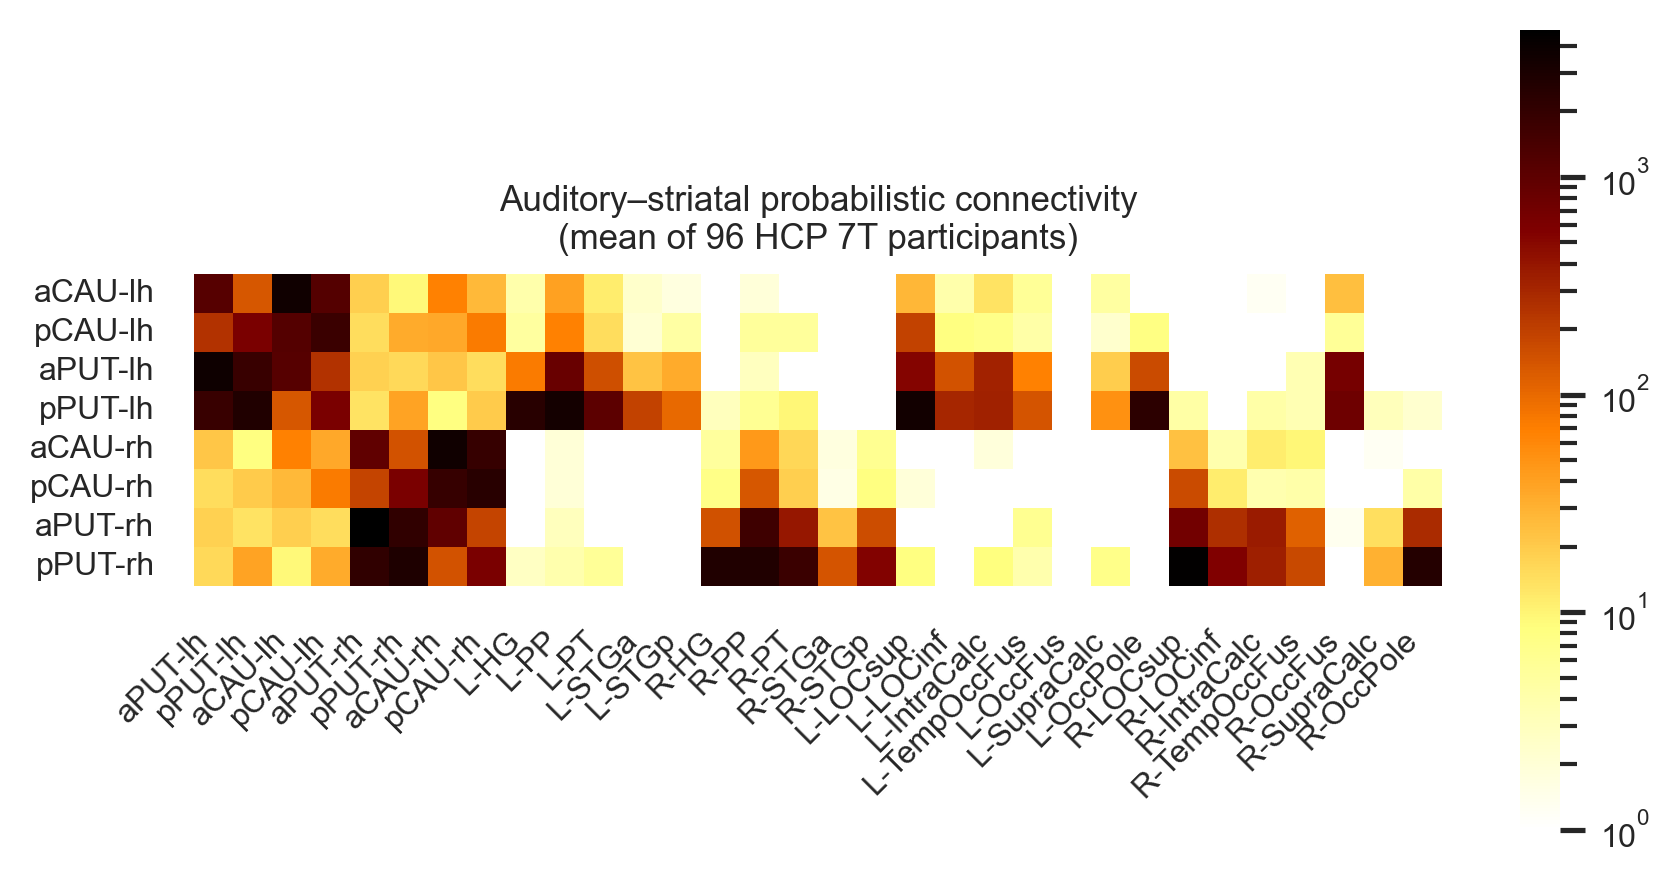

In [35]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

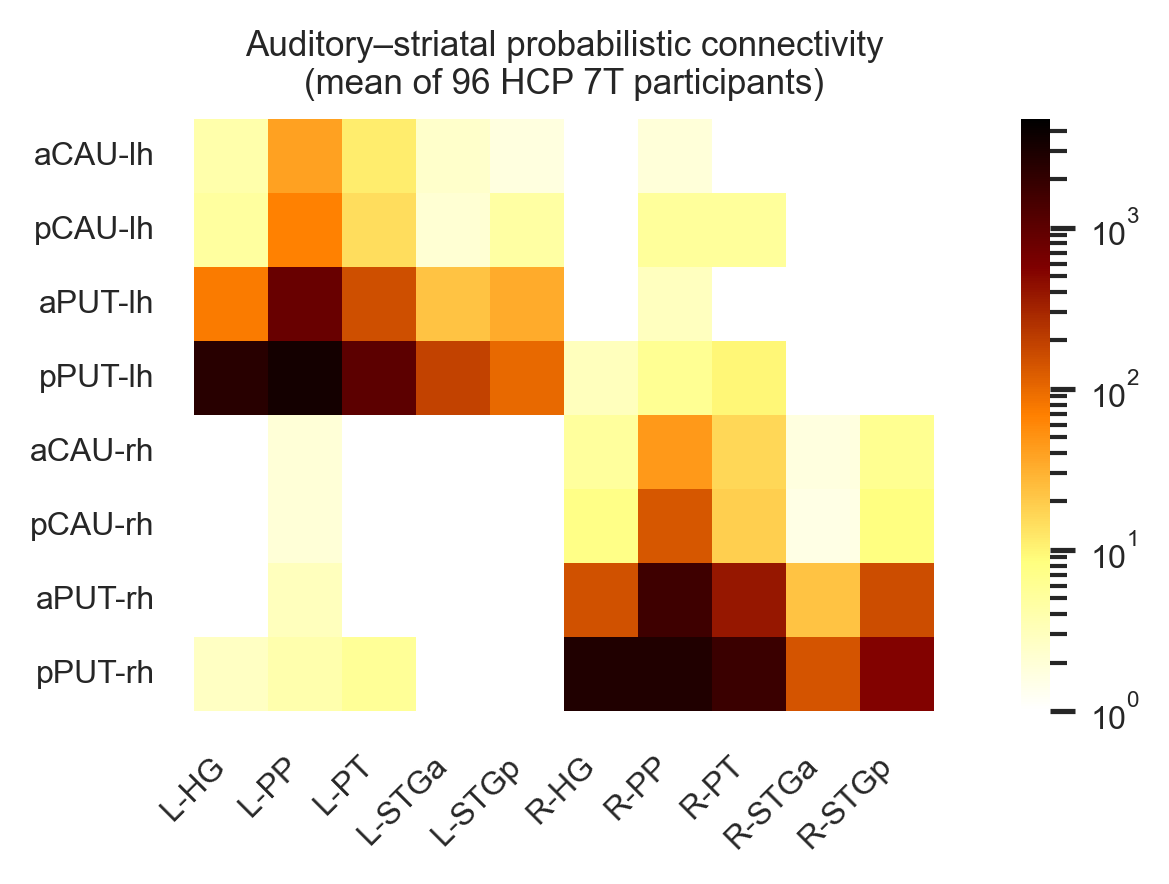

In [36]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

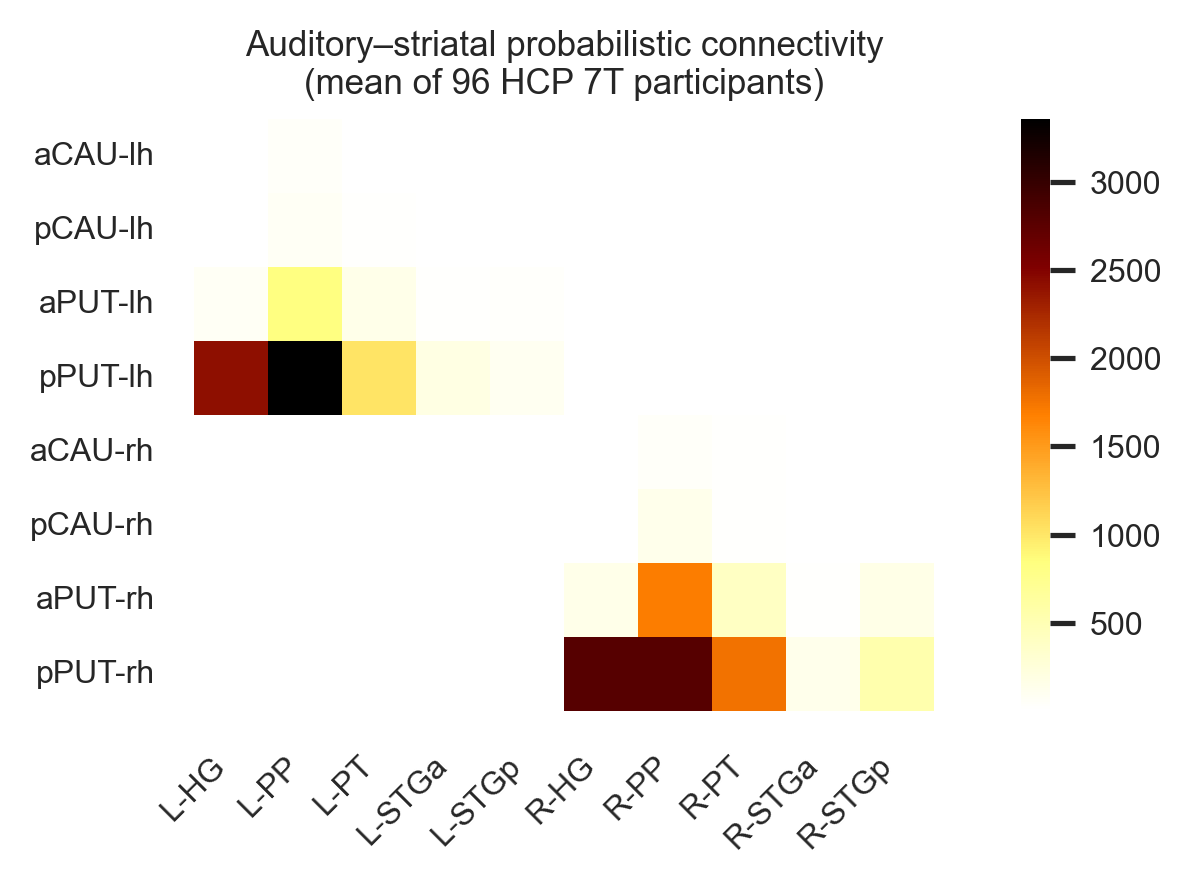

In [37]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            #norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

## volume-normalized streamline counts (**PRE- `-scale_invnodevol` application***)

In [131]:
roi_vols = dict()
vox_count_array = np.zeros(len(cp_list))
for rx, roi_fpath in enumerate(cp_list):
    roi_name = os.path.basename(roi_fpath).split('.')[0].split('carpet_')[1]

    roi_img = nib.load(roi_fpath)
    roi_data = roi_img.get_fdata()
    
    vox_count = np.count_nonzero(roi_data)
    vox_count_array[rx] = vox_count
    roi_vols[roi_name] = vox_count
    print(roi_name + ' voxel count: ' + str(vox_count))

print(f'\nmean ROI voxel count: {vox_count_array.mean():.02f}')

aCAU-lh voxel count: 1799
pCAU-lh voxel count: 1057
aPUT-lh voxel count: 3114
pPUT-lh voxel count: 3268
aCAU-rh voxel count: 1769
pCAU-rh voxel count: 1022
aPUT-rh voxel count: 3125
pPUT-rh voxel count: 3405

mean ROI voxel count: 2319.88


In [132]:
corrected_list = []
for rx, roi_name in enumerate(list(roi_vols.keys())):
    print(roi_name)
    roi_row = mean_df[mean_df.seed==roi_name]
    print(roi_row)

    roi_row_corrected = roi_row.iloc[0,2:].to_numpy() / roi_vols[roi_name] * vox_count_array.mean()
    print(roi_row_corrected)

    corrected_list.append(roi_row_corrected)

aCAU-lh
   mean_slcount     seed      aPUT-lh     pPUT-lh      aCAU-lh      pCAU-lh  \
2   7851.110578  aCAU-lh  1382.911924  173.184216  4523.746743  1440.836322   

     aPUT-rh    pPUT-rh    aCAU-rh    pCAU-rh  ...  L-OccFus  L-SupraCalc  \
2  22.550421  12.147108  82.526913  30.867949  ...       0.0     6.022249   

   L-OccPole  R-LOCsup  R-LOCinf  R-IntraCalc  R-TempOccFus   R-OccFus  \
2   0.005728  0.209947  0.007468     1.728977      0.927188  29.158787   

   R-SupraCalc  R-OccPole  
2     0.247837        0.0  

[1 rows x 34 columns]
[1783.314507364282 223.32725596706175 5833.533616724213 1858.0100959660515
 29.07957586679242 15.664131886720385 106.42141364922865 39.80532662490439
 7.35166918734536 62.35517097415068 20.959236128521265 3.8506168886016003
 3.00536657994816 0.31138620820536755 2.924800395689605 0.8358089363923589
 0.02693132779243294 0.06793973006436035 47.196679888046035
 6.589614392432624 21.53819861504515 8.719462407972223 0.0
 7.765905759502016 0.00738690372

In [133]:
'''left_caudate_vol_normalized = cxm_df.iloc[0,cortex_left_inds].to_numpy() / roi_vols['L-Caud'] * vox_count_array.mean()
left_putamen_vol_normalized = cxm_df.iloc[1,cortex_left_inds].to_numpy() / roi_vols['L-Put'] * vox_count_array.mean()
right_caudate_vol_normalized = cxm_df.iloc[2,cortex_right_inds].to_numpy() / roi_vols['R-Caud'] * vox_count_array.mean()
right_putamen_vol_normalized = cxm_df.iloc[3,cortex_right_inds].to_numpy() / roi_vols['R-Put'] * vox_count_array.mean()'''

"left_caudate_vol_normalized = cxm_df.iloc[0,cortex_left_inds].to_numpy() / roi_vols['L-Caud'] * vox_count_array.mean()\nleft_putamen_vol_normalized = cxm_df.iloc[1,cortex_left_inds].to_numpy() / roi_vols['L-Put'] * vox_count_array.mean()\nright_caudate_vol_normalized = cxm_df.iloc[2,cortex_right_inds].to_numpy() / roi_vols['R-Caud'] * vox_count_array.mean()\nright_putamen_vol_normalized = cxm_df.iloc[3,cortex_right_inds].to_numpy() / roi_vols['R-Put'] * vox_count_array.mean()"

### plot volume-corrected

In [134]:
cs_df = pd.DataFrame(data=corrected_list, 
                          columns=region_list,
                          index=list(roi_vols.keys()))
print(cs_df)


             aPUT-lh      pPUT-lh      aCAU-lh      pCAU-lh      aPUT-rh  \
aCAU-lh  1783.314507   223.327256  5833.533617  1858.010096    29.079576   
pCAU-lh   707.688303  1712.882619  3162.308574  5052.025294    39.805109   
aPUT-lh  3423.021188  1710.852088  1030.244958   240.214045    16.566530   
pPUT-lh  1630.230539  2459.428524   122.939331   554.013748    11.826753   
aCAU-rh    33.693389    12.458795   108.226186    50.297458  1597.813637   
pCAU-rh    40.825224    54.370053    70.068280   192.325954   524.411214   
aPUT-rh    16.508216    12.367945    16.740530    13.463680  4601.805343   
pPUT-rh    13.057252    32.366672     8.275998    28.123982  1860.347817   

             pPUT-rh      aCAU-rh      pCAU-rh         L-HG         L-PP  ...  \
aCAU-lh    15.664132   106.421414    39.805327     7.351669    62.355171  ...   
pCAU-lh    90.598069    84.178053   185.957545    15.900017   184.657249  ...   
aPUT-lh    14.277439    19.140528    13.398645    72.105091   765.416192

In [135]:
'''
left_cs_df = pd.DataFrame(data=[left_caudate_vol_normalized, left_putamen_vol_normalized], 
                          columns=region_list[cortex_left_inds],
                          index=region_list[caud_put_left_inds])
print(left_cs_df)

right_cs_df = pd.DataFrame(data=[right_caudate_vol_normalized, right_putamen_vol_normalized], 
                          columns=region_list[cortex_right_inds],
                          index=region_list[caud_put_right_inds])
print(right_cs_df)
'''

'\nleft_cs_df = pd.DataFrame(data=[left_caudate_vol_normalized, left_putamen_vol_normalized], \n                          columns=region_list[cortex_left_inds],\n                          index=region_list[caud_put_left_inds])\nprint(left_cs_df)\n\nright_cs_df = pd.DataFrame(data=[right_caudate_vol_normalized, right_putamen_vol_normalized], \n                          columns=region_list[cortex_right_inds],\n                          index=region_list[caud_put_right_inds])\nprint(right_cs_df)\n'

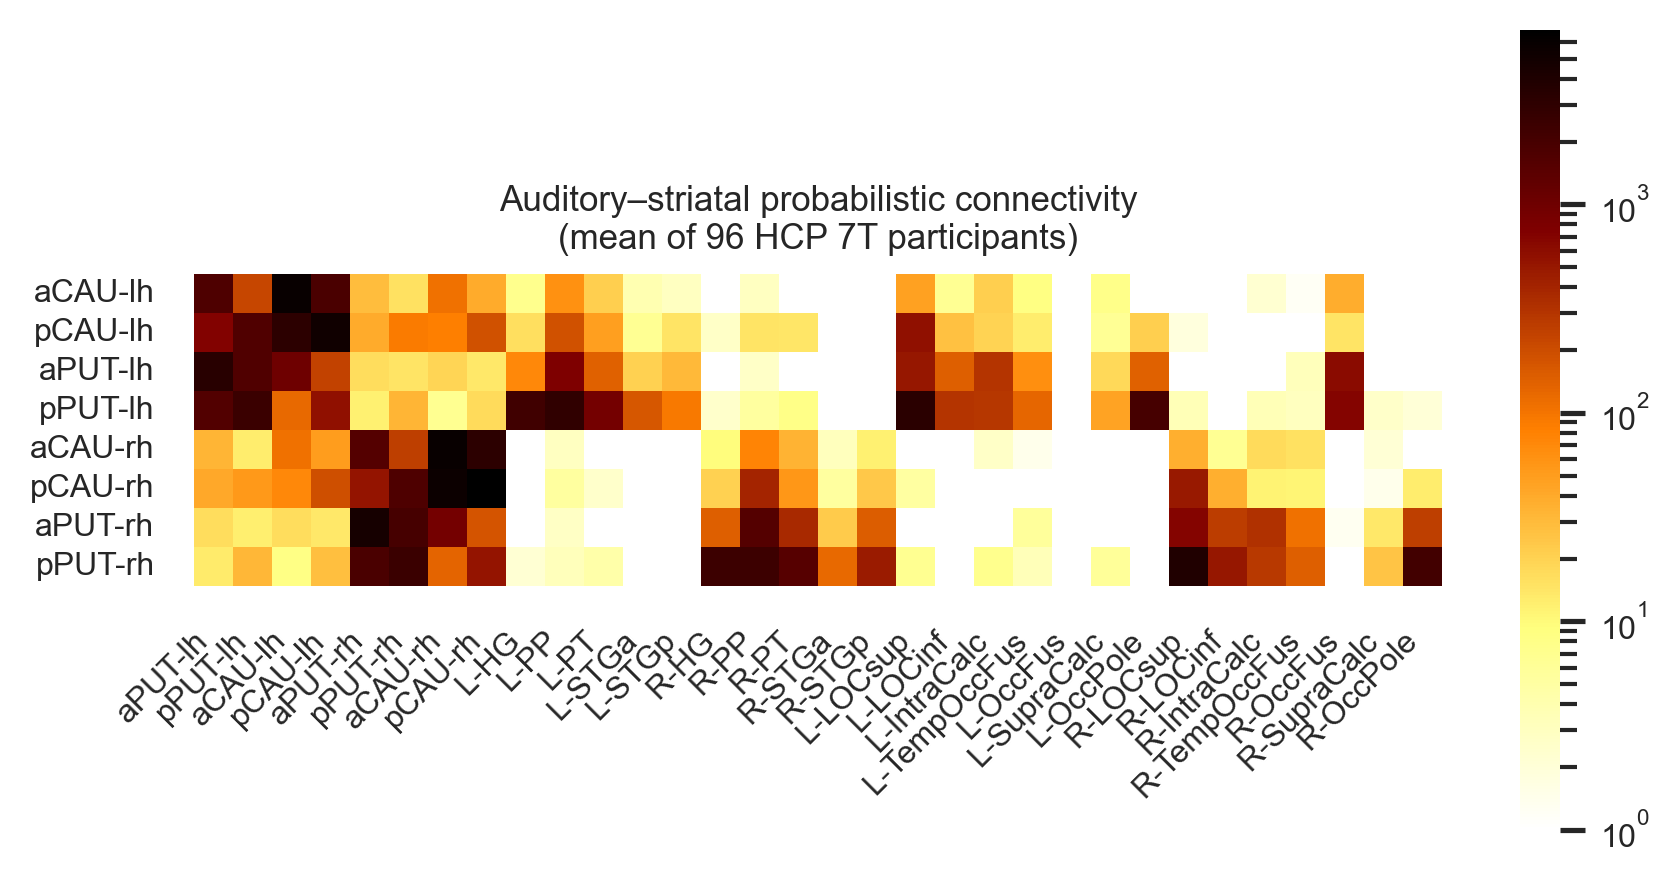

In [136]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df, ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

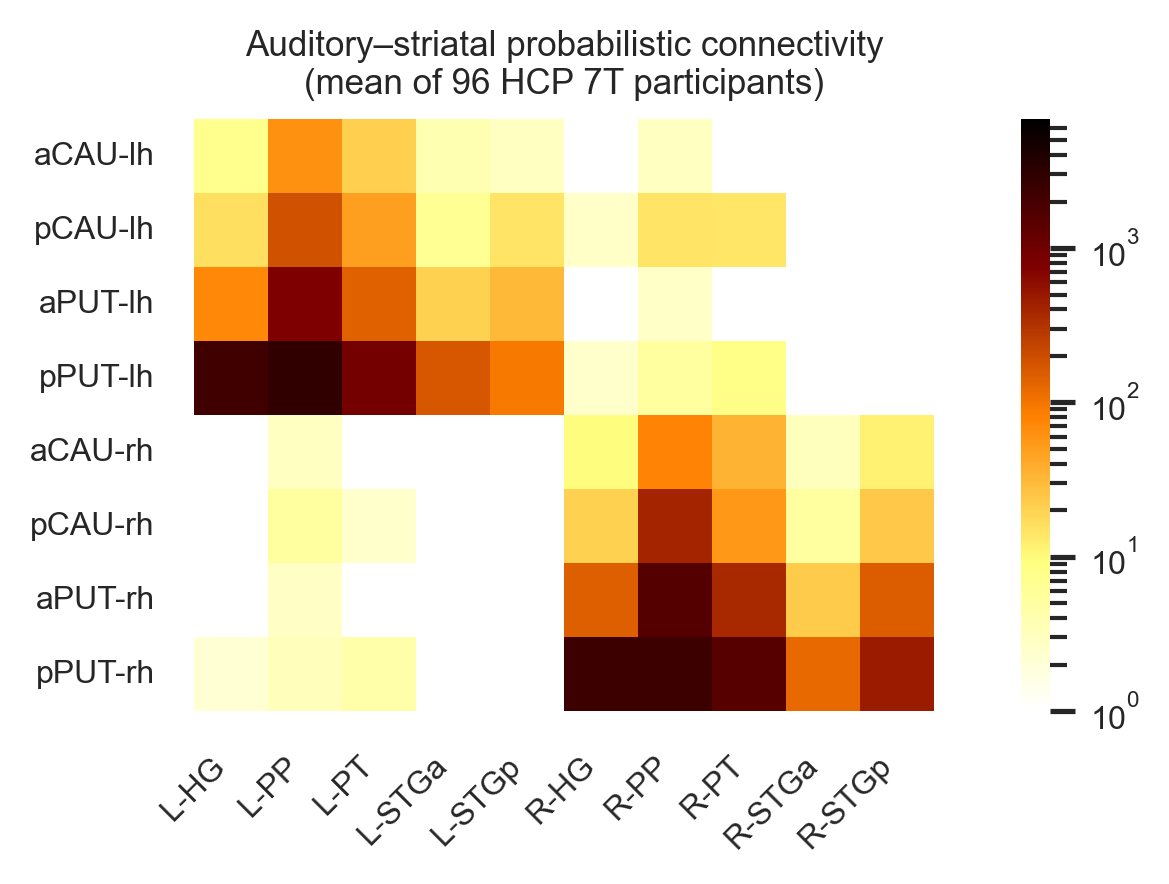

In [137]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(6,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

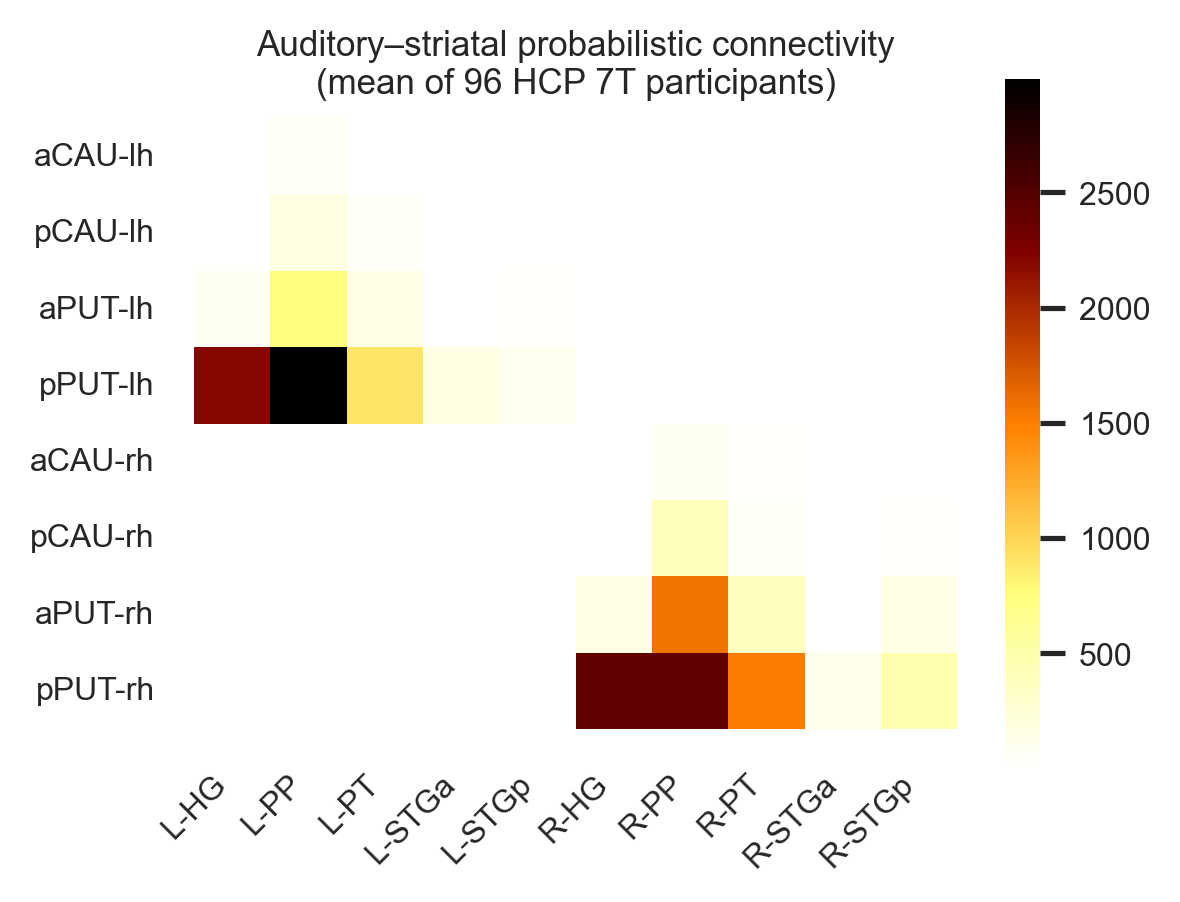

In [138]:
df_max = cs_df.to_numpy().max()

sns.set(font_scale=.7)
sns.set_style("white")

f, ax = plt.subplots(1,1,figsize=(4,3), dpi=300)

sns.heatmap(cs_df.iloc[:,8:18], ax=ax, cmap="afmhot_r",
            #norm=colors.LogNorm(vmin=1, vmax=df_max),
            square=True)
ax.set_title(f'Auditory–striatal probabilistic connectivity\n(mean of {num_participants} HCP 7T participants)');
#ax.tick_params(rotation=45, ha='right');
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

#sns.heatmap(right_cs_df, ax=ax[1], cmap="afmhot_r",
#            norm=colors.LogNorm(vmin=1, vmax=df_max),)
#ax[1].tick_params(rotation=45);
#ax[1].set_title('Right hemisphere auditory–striatal probabilistic connectivity');
f.tight_layout()

In [139]:
from mne_connectivity.viz import plot_connectivity_circle

In [140]:
cs_df.to_numpy().shape

(8, 32)

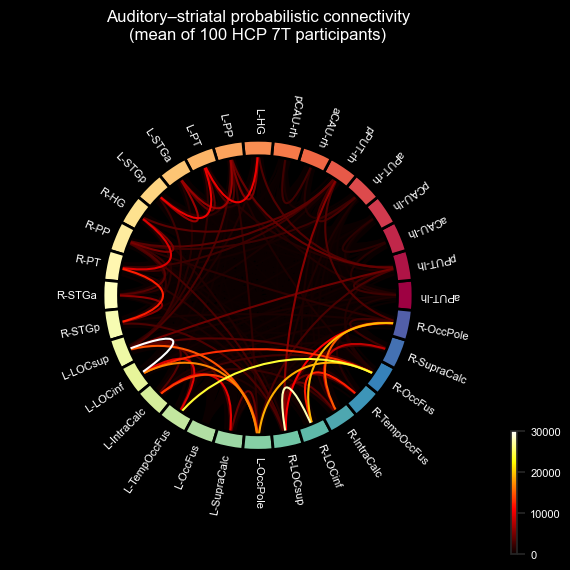

In [141]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor="black", subplot_kw=dict(polar=True))
plot_connectivity_circle(
    plot_df.to_numpy(),
    plot_df.columns,
    #n_lines=300,
    title="Auditory–striatal probabilistic connectivity\n(mean of 100 HCP 7T participants)",
    ax=ax,
)
fig.tight_layout()

## Combine separate participants into single dataframe

In [43]:
participant_df_list = []
for i in range(connmats.shape[0]):
    df = pd.DataFrame(connmats[i], index=region_list, columns=region_list)
    df['participant_id'] = i
    participant_df_list.append(df)

In [44]:
striatum_rois = [r for r in region_list if r.startswith(('aPUT', 'pPUT', 'aCAU', 'pCAU'))]
cortex_rois = [r for r in region_list if r.startswith(('L-', 'R-'))]

filtered_df_list = []
for df in participant_df_list:
    sub_df = df.loc[striatum_rois, cortex_rois]
    sub_df['participant_id'] = df['participant_id'].iloc[0]
    filtered_df_list.append(sub_df)

In [45]:
rostral_caudal_map = {
    'aPUT-lh': 'Rostral', 'aCAU-lh': 'Rostral',
    'pPUT-lh': 'Caudal', 'pCAU-lh': 'Caudal',
    'aPUT-rh': 'Rostral', 'aCAU-rh': 'Rostral',
    'pPUT-rh': 'Caudal', 'pCAU-rh': 'Caudal'
}

for df in filtered_df_list:
    df['Rostral_Caudal'] = df.index.map(rostral_caudal_map)

In [46]:
caudate_putamen_map = {
    'aPUT-lh': 'Putamen', 'aCAU-lh': 'Caudate',
    'pPUT-lh': 'Putamen', 'pCAU-lh': 'Caudate',
    'aPUT-rh': 'Putamen', 'aCAU-rh': 'Caudate',
    'pPUT-rh': 'Putamen', 'pCAU-rh': 'Caudate'
}

for df in filtered_df_list:
    df['Caudate_Putamen'] = df.index.map(caudate_putamen_map)

In [47]:
all_df = pd.concat(filtered_df_list)
all_df = all_df.reset_index().rename(columns={'index': 'Striatum_ROI'})

In [48]:

# Melt to long format
all_long_df = all_df.melt(id_vars=['participant_id', 'Striatum_ROI', 'Rostral_Caudal', 'Caudate_Putamen'], 
                      value_vars=cortex_rois, 
                      var_name='Cortex_ROI', value_name='Connectivity')


In [49]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity
0,0,aPUT-lh,Rostral,Putamen,L-HG,65.834432
1,0,pPUT-lh,Caudal,Putamen,L-HG,3104.246460
2,0,aCAU-lh,Rostral,Caudate,L-HG,4.357843
3,0,pCAU-lh,Caudal,Caudate,L-HG,19.704495
4,0,aPUT-rh,Rostral,Putamen,L-HG,0.280541


In [50]:
# Add hemisphere info before stripping labels
def get_striatum_hemisphere(roi):
    if roi.endswith('-lh'):
        return 'Left'
    elif roi.endswith('-rh'):
        return 'Right'
    else:
        return None

def get_cortex_hemisphere(roi):
    if roi.startswith('L-'):
        return 'Left'
    elif roi.startswith('R-'):
        return 'Right'
    else:
        return None

all_long_df['striatum_hemisphere'] = all_long_df['Striatum_ROI'].apply(get_striatum_hemisphere)
all_long_df['cortex_hemisphere'] = all_long_df['Cortex_ROI'].apply(get_cortex_hemisphere)

# Keep only rows where hemispheres match
all_long_df = all_long_df[all_long_df['striatum_hemisphere'] == all_long_df['cortex_hemisphere']]

# Optionally, create a single 'hemisphere' column and strip hemisphere labels
all_long_df['hemisphere'] = all_long_df['striatum_hemisphere']
all_long_df['Striatum_ROI'] = all_long_df['Striatum_ROI'].apply(lambda x: x[:-3] if x.endswith(('-lh', '-rh')) else x)
all_long_df['Cortex_ROI'] = all_long_df['Cortex_ROI'].apply(lambda x: x[2:] if x.startswith(('L-', 'R-')) else x)

In [51]:
all_long_df.shape

(9216, 9)

In [52]:
all_long_df.head()

,participant_id,Striatum_ROI,Rostral_Caudal,Caudate_Putamen,Cortex_ROI,Connectivity,striatum_hemisphere,cortex_hemisphere,hemisphere
0,0,aPUT,Rostral,Putamen,HG,65.834432,Left,Left,Left
1,0,pPUT,Caudal,Putamen,HG,3104.246460,Left,Left,Left
2,0,aCAU,Rostral,Caudate,HG,4.357843,Left,Left,Left
3,0,pCAU,Caudal,Caudate,HG,19.704495,Left,Left,Left
8,1,aPUT,Rostral,Putamen,HG,71.307784,Left,Left,Left


In [53]:
all_long_df.Cortex_ROI.unique()

array(['HG', 'PP', 'PT', 'STGa', 'STGp', 'LOCsup', 'LOCinf', 'IntraCalc',
       'TempOccFus', 'OccFus', 'SupraCalc', 'OccPole'], dtype=object)

In [55]:
auditory_rois = ['HG', 'PP', 'PT', 'STGp', 'STGa']
long_df = all_long_df[all_long_df['Cortex_ROI'].isin(auditory_rois)]


## Across-participant statistics

In [56]:
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

### All factors

In [57]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,1052.4535,1.0000,95.0000,0.0000
Rostral_Caudal,645.1297,1.0000,95.0000,0.0000
Cortex_ROI,597.0560,4.0000,380.0000,0.0000
hemisphere,53.4046,1.0000,95.0000,0.0000
Caudate_Putamen:Rostral_Caudal,646.7448,1.0000,95.0000,0.0000
Caudate_Putamen:Cortex_ROI,567.4454,4.0000,380.0000,0.0000
Rostral_Caudal:Cortex_ROI,209.6879,4.0000,380.0000,0.0000
Caudate_Putamen:hemisphere,47.6857,1.0000,95.0000,0.0000
Rostral_Caudal:hemisphere,1.2391,1.0000,95.0000,0.2685
Cortex_ROI:hemisphere,16.9873,4.0000,380.0000,0.0000


### No hemisphere

In [58]:
# Mixed-Effects ANOVA with all factors and interactions
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Rostral_Caudal', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,1052.4535,1.0000,95.0000,0.0000
Rostral_Caudal,645.1297,1.0000,95.0000,0.0000
Cortex_ROI,597.0560,4.0000,380.0000,0.0000
Caudate_Putamen:Rostral_Caudal,646.7448,1.0000,95.0000,0.0000
Caudate_Putamen:Cortex_ROI,567.4454,4.0000,380.0000,0.0000
Rostral_Caudal:Cortex_ROI,209.6879,4.0000,380.0000,0.0000
Caudate_Putamen:Rostral_Caudal:Cortex_ROI,209.4019,4.0000,380.0000,0.0000


### Caudate–Putamen

In [59]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Caudate_Putamen', 'Cortex_ROI', 'hemisphere',]).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Caudate_Putamen,1052.4535,1.0000,95.0000,0.0000
Cortex_ROI,597.0560,4.0000,380.0000,0.0000
hemisphere,53.4046,1.0000,95.0000,0.0000
Caudate_Putamen:Cortex_ROI,567.4454,4.0000,380.0000,0.0000
Caudate_Putamen:hemisphere,47.6857,1.0000,95.0000,0.0000
Cortex_ROI:hemisphere,16.9873,4.0000,380.0000,0.0000
Caudate_Putamen:Cortex_ROI:hemisphere,18.5662,4.0000,380.0000,0.0000


In [73]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Caudate_Putamen', 'Cortex_ROI'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Caudate_Putamen', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Caudate_Putamen', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


/Users/dsj3886/miniconda3/envs/py24/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:7321: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)


,Contrast,Caudate_Putamen,A,B,T,dof,p_unc,p_corr,BF10
0,Caudate_Putamen,-,Caudate,Putamen,-32.441539,95.0,3.425731e-53,NaN,4.392e+49
1,Cortex_ROI,-,HG,PP,-14.200778,95.0,3.184886e-25,3.981107e-25,1.228e+22
2,Cortex_ROI,-,HG,PT,13.981001,95.0,8.719105e-25,9.687895e-25,4.574e+21
3,Cortex_ROI,-,HG,STGa,26.800527,95.0,4.406401e-46,1.468800e-45,4.207e+42
4,Cortex_ROI,-,HG,STGp,24.141927,95.0,2.555949e-42,6.389872e-42,8.151e+38
5,Cortex_ROI,-,PP,PT,21.411945,95.0,3.951433e-38,6.585722e-38,6.046e+34
6,Cortex_ROI,-,PP,STGa,30.434877,95.0,8.712362e-51,8.712362e-50,1.85e+47
7,Cortex_ROI,-,PP,STGp,28.268477,95.0,4.860395e-48,2.430198e-47,3.596e+44
8,Cortex_ROI,-,PT,STGa,22.620853,95.0,4.995657e-40,9.991314e-40,4.49e+36
9,Cortex_ROI,-,PT,STGp,20.155342,95.0,4.429104e-36,6.327292e-36,5.785e+32


In [74]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Cortex_ROI', 'Caudate_Putamen', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-14.200778,95.0,3.184886e-25,3.981107e-25,1.228e+22
1,Cortex_ROI,-,HG,PT,13.981001,95.0,8.719105e-25,9.687895e-25,4.574e+21
2,Cortex_ROI,-,HG,STGa,26.800527,95.0,4.406401e-46,1.468800e-45,4.207e+42
3,Cortex_ROI,-,HG,STGp,24.141927,95.0,2.555949e-42,6.389872e-42,8.151e+38
4,Cortex_ROI,-,PP,PT,21.411945,95.0,3.951433e-38,6.585722e-38,6.046e+34
5,Cortex_ROI,-,PP,STGa,30.434877,95.0,8.712362e-51,8.712362e-50,1.85e+47
6,Cortex_ROI,-,PP,STGp,28.268477,95.0,4.860395e-48,2.430198e-47,3.596e+44
7,Cortex_ROI,-,PT,STGa,22.620853,95.0,4.995657e-40,9.991314e-40,4.49e+36
8,Cortex_ROI,-,PT,STGp,20.155342,95.0,4.429104e-36,6.327292e-36,5.785e+32
9,Cortex_ROI,-,STGa,STGp,-12.293002,95.0,2.385867e-21,2.385867e-21,1.967e+18


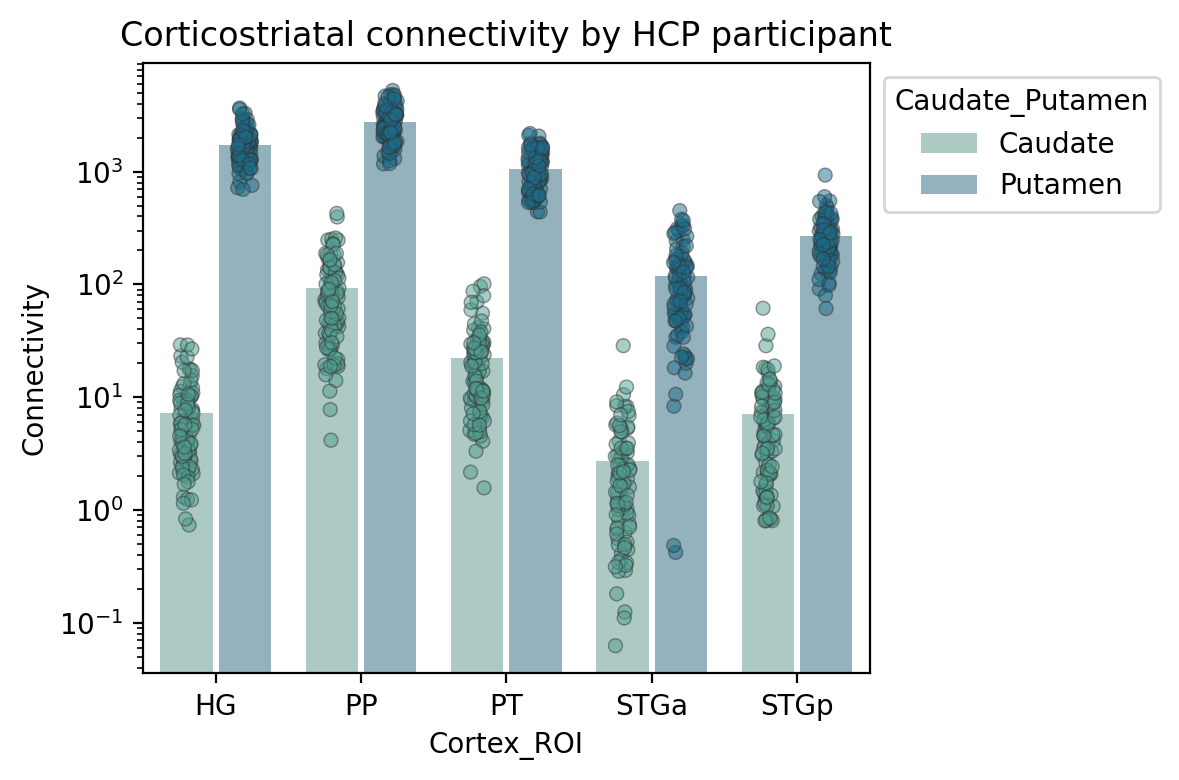

In [75]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='Cortex_ROI', y='Connectivity', 
              hue='Caudate_Putamen', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


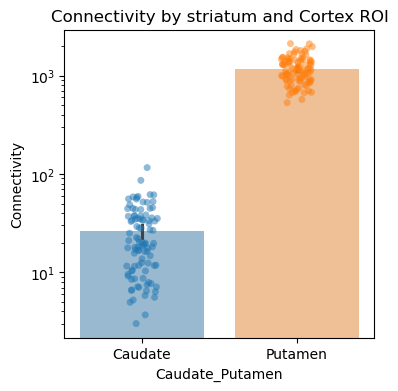

In [76]:
df_collapsed = long_df.groupby(["participant_id", 'Caudate_Putamen',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Caudate_Putamen', y='Connectivity', hue='Caudate_Putamen', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by striatum and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [81]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Cortex_ROI',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere,-,Left,Right,-7.307843,95.0,8.401558e-11,NaN,1.096e+08
1,Cortex_ROI,-,HG,PP,-14.200778,95.0,3.184886e-25,3.981107e-25,1.228e+22
2,Cortex_ROI,-,HG,PT,13.981001,95.0,8.719105e-25,9.687895e-25,4.574e+21
3,Cortex_ROI,-,HG,STGa,26.800527,95.0,4.406401e-46,1.468800e-45,4.207e+42
4,Cortex_ROI,-,HG,STGp,24.141927,95.0,2.555949e-42,6.389872e-42,8.151e+38
5,Cortex_ROI,-,PP,PT,21.411945,95.0,3.951433e-38,6.585722e-38,6.046e+34
6,Cortex_ROI,-,PP,STGa,30.434877,95.0,8.712362e-51,8.712362e-50,1.85e+47
7,Cortex_ROI,-,PP,STGp,28.268477,95.0,4.860395e-48,2.430198e-47,3.596e+44
8,Cortex_ROI,-,PT,STGa,22.620853,95.0,4.995657e-40,9.991314e-40,4.49e+36
9,Cortex_ROI,-,PT,STGp,20.155342,95.0,4.429104e-36,6.327292e-36,5.785e+32


In [82]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-14.200778,95.0,3.184886e-25,3.981107e-25,1.228e+22
1,Cortex_ROI,-,HG,PT,13.981001,95.0,8.719105e-25,9.687895e-25,4.574e+21
2,Cortex_ROI,-,HG,STGa,26.800527,95.0,4.406401e-46,1.468800e-45,4.207e+42
3,Cortex_ROI,-,HG,STGp,24.141927,95.0,2.555949e-42,6.389872e-42,8.151e+38
4,Cortex_ROI,-,PP,PT,21.411945,95.0,3.951433e-38,6.585722e-38,6.046e+34
5,Cortex_ROI,-,PP,STGa,30.434877,95.0,8.712362e-51,8.712362e-50,1.85e+47
6,Cortex_ROI,-,PP,STGp,28.268477,95.0,4.860395e-48,2.430198e-47,3.596e+44
7,Cortex_ROI,-,PT,STGa,22.620853,95.0,4.995657e-40,9.991314e-40,4.49e+36
8,Cortex_ROI,-,PT,STGp,20.155342,95.0,4.429104e-36,6.327292e-36,5.785e+32
9,Cortex_ROI,-,STGa,STGp,-12.293002,95.0,2.385867e-21,2.385867e-21,1.967e+18


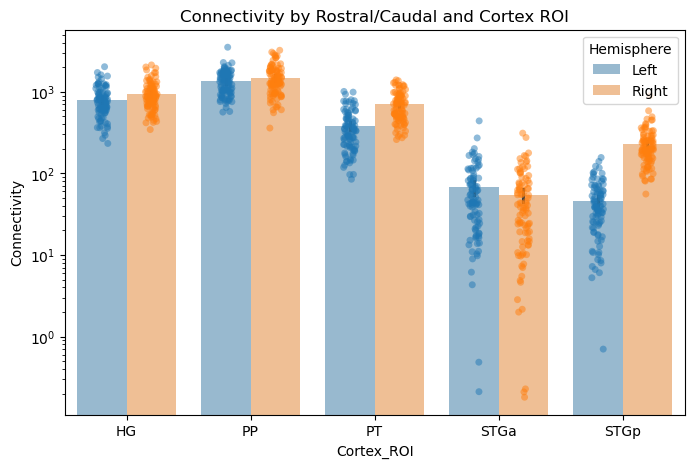

In [83]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [84]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Striatum_ROI,-,aCAU,aPUT,-20.173339,95.0,4.134225e-36,6.201338e-36,6.192e+32
1,Striatum_ROI,-,aCAU,pCAU,-5.572913,95.0,2.334785e-07,2.334785e-07,5.541e+04
2,Striatum_ROI,-,aCAU,pPUT,-30.881961,95.0,2.472488e-51,8.083727e-51,6.418e+47
3,Striatum_ROI,-,aPUT,pCAU,18.927598,95.0,5.339186e-34,6.407023e-34,5.167e+30
4,Striatum_ROI,-,aPUT,pPUT,-25.447941,95.0,3.327209e-44,6.654418e-44,5.902e+40
5,Striatum_ROI,-,pCAU,pPUT,-30.851259,95.0,2.694576e-51,8.083727e-51,5.895e+47
6,hemisphere,-,Left,Right,-7.307843,95.0,8.401558e-11,NaN,1.096e+08
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-2.360144,95.0,2.031281e-02,2.031281e-02,1.572
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-11.074926,95.0,8.531636e-19,3.412654e-18,6.29e+15
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-5.501740,95.0,3.173584e-07,6.347168e-07,4.141e+04


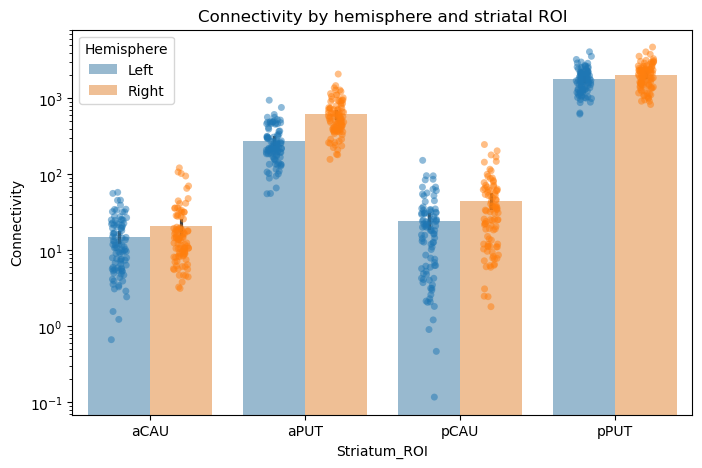

In [85]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

### Rostral–caudal

In [86]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(long_df, 
              aggregate_func='mean',
              depvar='Connectivity', 
              subject='participant_id', 
              within=['Rostral_Caudal', 'hemisphere', 'Cortex_ROI']).fit()

# Display results
aov.summary()

,F Value,Num DF,Den DF,Pr > F
Rostral_Caudal,645.1297,1.0000,95.0000,0.0000
hemisphere,53.4046,1.0000,95.0000,0.0000
Cortex_ROI,597.0560,4.0000,380.0000,0.0000
Rostral_Caudal:hemisphere,1.2391,1.0000,95.0000,0.2685
Rostral_Caudal:Cortex_ROI,209.6879,4.0000,380.0000,0.0000
hemisphere:Cortex_ROI,16.9873,4.0000,380.0000,0.0000
Rostral_Caudal:hemisphere:Cortex_ROI,65.6489,4.0000,380.0000,0.0000


In [87]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'hemisphere', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'hemisphere', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p_unc,p_corr,BF10
0,hemisphere,-,Left,Right,-7.307843,95.0,8.401558e-11,NaN,1.096e+08
1,Rostral_Caudal,-,Caudal,Rostral,25.399403,95.0,3.898147e-44,NaN,5.048e+40
2,hemisphere * Rostral_Caudal,Left,Caudal,Rostral,24.246789,95.0,1.792440e-42,3.584881e-42,1.157e+39
3,hemisphere * Rostral_Caudal,Right,Caudal,Rostral,20.120985,95.0,5.052226e-36,5.052226e-36,5.082e+32


In [88]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Rostral_Caudal', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Rostral_Caudal', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Rostral_Caudal', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Rostral_Caudal,A,B,T,dof,p_unc,p_corr,BF10
0,Rostral_Caudal,-,Caudal,Rostral,25.399403,95.0,3.898147e-44,NaN,5.048e+40
1,hemisphere,-,Left,Right,-7.307843,95.0,8.401558e-11,NaN,1.096e+08
2,Rostral_Caudal * hemisphere,Caudal,Left,Right,-3.839165,95.0,2.225102e-04,2.225102e-04,89.208
3,Rostral_Caudal * hemisphere,Rostral,Left,Right,-11.105375,95.0,7.355628e-19,1.471126e-18,7.27e+15


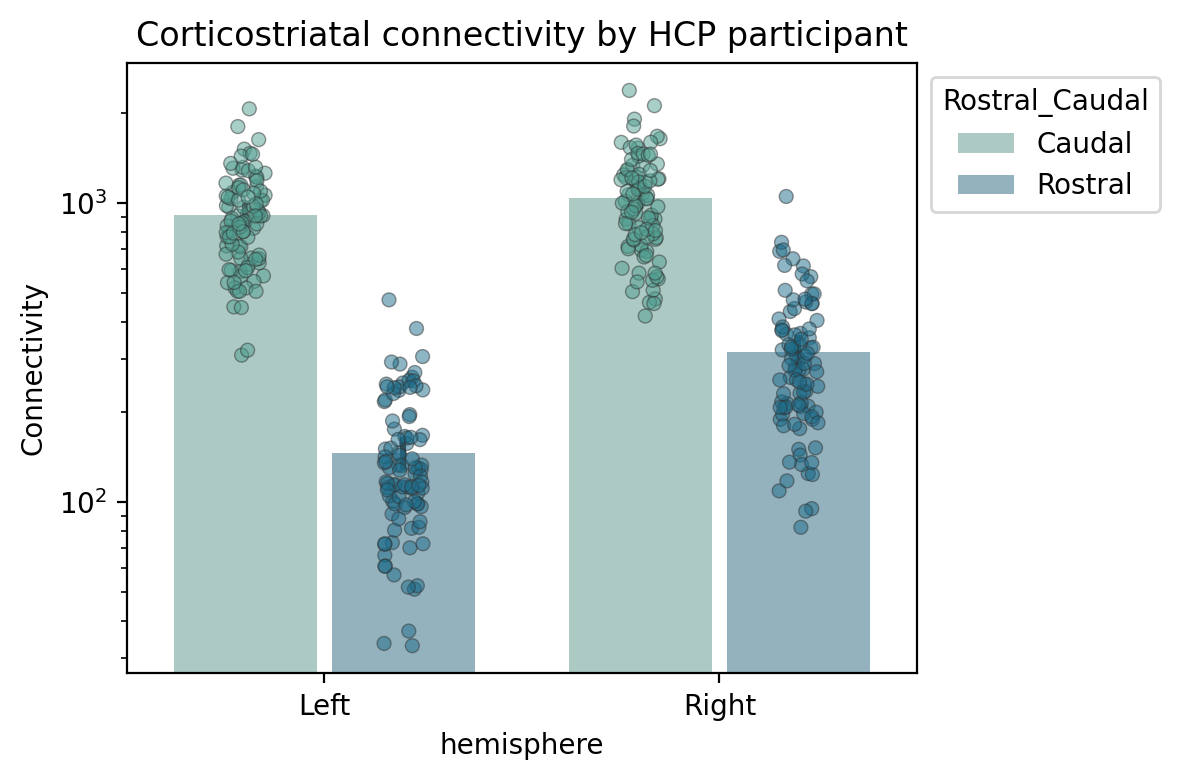

In [89]:
df_collapsed = long_df.groupby(["participant_id", 'hemisphere', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=200)

sns.barplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',  
              #fliersize=0, whis=(8, 92),
              #linewidth=1.5,
              alpha=0.5, gap=0.1, #fill=False,
              #legend=None,
              ax=ax)
sns.stripplot(data=df_collapsed, 
              x='hemisphere', y='Connectivity', 
              hue='Rostral_Caudal', #hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              jitter=True,
              linewidth=0.5,
              alpha=0.5,
              legend=None,
              ax=ax)

#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Corticostriatal connectivity by HCP participant');
plt.yscale('log')
#ax.set_ylim([-5, 5])

fig.tight_layout()


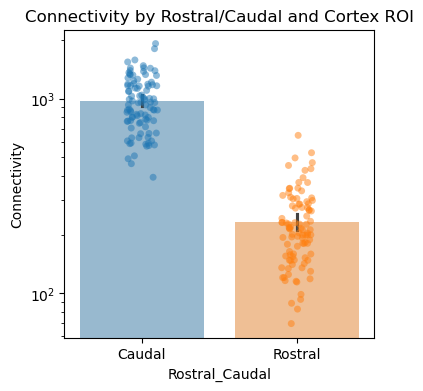

In [90]:
df_collapsed = long_df.groupby(["participant_id", 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(4, 4))
sns.barplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)
sns.stripplot(x='Rostral_Caudal', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5)

plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')
plt.show()

In [91]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'Rostral_Caudal',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-14.200778,95.0,3.184886e-25,3.981107e-25,1.228e+22
1,Cortex_ROI,-,HG,PT,13.981001,95.0,8.719105e-25,9.687895e-25,4.574e+21
2,Cortex_ROI,-,HG,STGa,26.800527,95.0,4.406401e-46,1.468800e-45,4.207e+42
3,Cortex_ROI,-,HG,STGp,24.141927,95.0,2.555949e-42,6.389872e-42,8.151e+38
4,Cortex_ROI,-,PP,PT,21.411945,95.0,3.951433e-38,6.585722e-38,6.046e+34
5,Cortex_ROI,-,PP,STGa,30.434877,95.0,8.712362e-51,8.712362e-50,1.85e+47
6,Cortex_ROI,-,PP,STGp,28.268477,95.0,4.860395e-48,2.430198e-47,3.596e+44
7,Cortex_ROI,-,PT,STGa,22.620853,95.0,4.995657e-40,9.991314e-40,4.49e+36
8,Cortex_ROI,-,PT,STGp,20.155342,95.0,4.429104e-36,6.327292e-36,5.785e+32
9,Cortex_ROI,-,STGa,STGp,-12.293002,95.0,2.385867e-21,2.385867e-21,1.967e+18


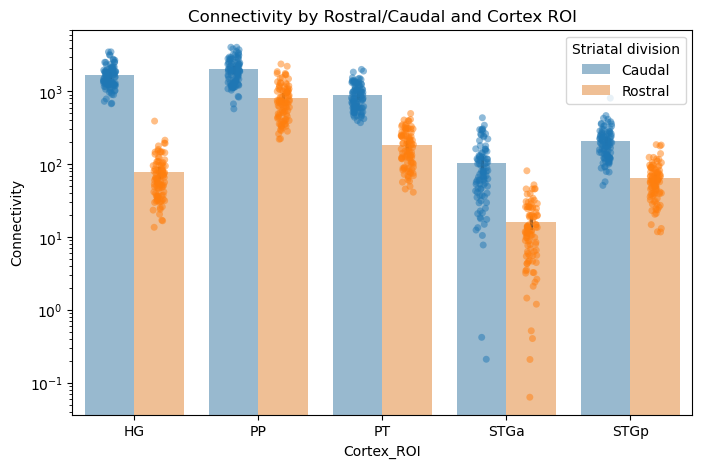

In [94]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'Rostral_Caudal',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='Rostral_Caudal', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Striatal division') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [95]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=[ 'Cortex_ROI', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast',  'Cortex_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'Cortex_ROI', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Cortex_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Cortex_ROI,-,HG,PP,-14.200778,95.0,3.184886e-25,3.981107e-25,1.228e+22
1,Cortex_ROI,-,HG,PT,13.981001,95.0,8.719105e-25,9.687895e-25,4.574e+21
2,Cortex_ROI,-,HG,STGa,26.800527,95.0,4.406401e-46,1.468800e-45,4.207e+42
3,Cortex_ROI,-,HG,STGp,24.141927,95.0,2.555949e-42,6.389872e-42,8.151e+38
4,Cortex_ROI,-,PP,PT,21.411945,95.0,3.951433e-38,6.585722e-38,6.046e+34
5,Cortex_ROI,-,PP,STGa,30.434877,95.0,8.712362e-51,8.712362e-50,1.85e+47
6,Cortex_ROI,-,PP,STGp,28.268477,95.0,4.860395e-48,2.430198e-47,3.596e+44
7,Cortex_ROI,-,PT,STGa,22.620853,95.0,4.995657e-40,9.991314e-40,4.49e+36
8,Cortex_ROI,-,PT,STGp,20.155342,95.0,4.429104e-36,6.327292e-36,5.785e+32
9,Cortex_ROI,-,STGa,STGp,-12.293002,95.0,2.385867e-21,2.385867e-21,1.967e+18


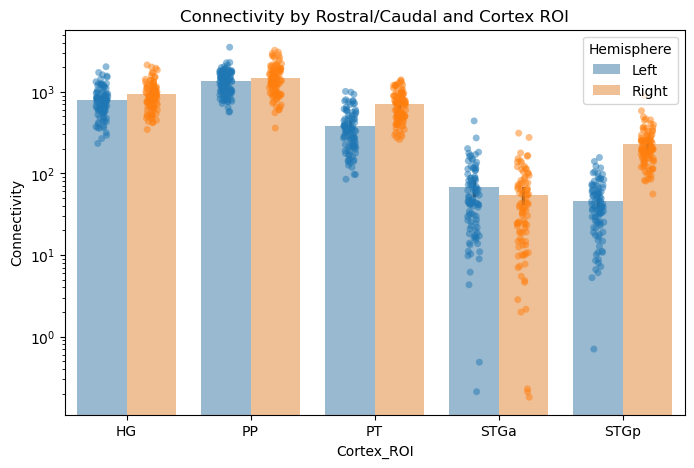

In [97]:
df_collapsed = long_df.groupby(["participant_id", 'Cortex_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Cortex_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by Rostral/Caudal and Cortex ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()

In [98]:

# Pairwise comparisons for region with FDR correction
pairwise = pg.pairwise_tests(data=long_df,
                             dv='Connectivity', 
                             within=['Striatum_ROI', 'hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

#pairwise_interaction = pairwise[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise[['Contrast', 'Striatum_ROI', 'A', 'B', 'T', 'dof', 'p_unc', 'p_corr', 'BF10']]
#print(pairwise)

Available columns: Index(['Contrast', 'Striatum_ROI', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p_unc', 'p_corr', 'p_adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Striatum_ROI,A,B,T,dof,p_unc,p_corr,BF10
0,Striatum_ROI,-,aCAU,aPUT,-20.173339,95.0,4.134225e-36,6.201338e-36,6.192e+32
1,Striatum_ROI,-,aCAU,pCAU,-5.572913,95.0,2.334785e-07,2.334785e-07,5.541e+04
2,Striatum_ROI,-,aCAU,pPUT,-30.881961,95.0,2.472488e-51,8.083727e-51,6.418e+47
3,Striatum_ROI,-,aPUT,pCAU,18.927598,95.0,5.339186e-34,6.407023e-34,5.167e+30
4,Striatum_ROI,-,aPUT,pPUT,-25.447941,95.0,3.327209e-44,6.654418e-44,5.902e+40
5,Striatum_ROI,-,pCAU,pPUT,-30.851259,95.0,2.694576e-51,8.083727e-51,5.895e+47
6,hemisphere,-,Left,Right,-7.307843,95.0,8.401558e-11,NaN,1.096e+08
7,Striatum_ROI * hemisphere,aCAU,Left,Right,-2.360144,95.0,2.031281e-02,2.031281e-02,1.572
8,Striatum_ROI * hemisphere,aPUT,Left,Right,-11.074926,95.0,8.531636e-19,3.412654e-18,6.29e+15
9,Striatum_ROI * hemisphere,pCAU,Left,Right,-5.501740,95.0,3.173584e-07,6.347168e-07,4.141e+04


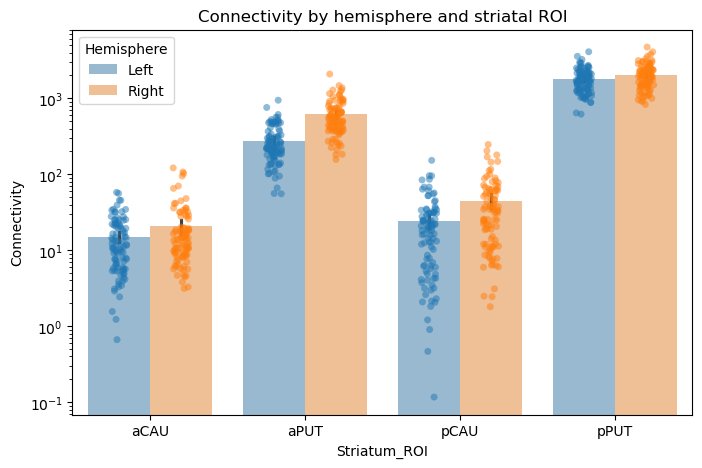

In [99]:
df_collapsed = long_df.groupby(["participant_id", 'Striatum_ROI', 'hemisphere',], 
                                       as_index=False).agg({"Connectivity": "mean"})
plt.figure(figsize=(8, 5))
sns.barplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, alpha=0.5, )#fliersize=0)
sns.stripplot(x='Striatum_ROI', y='Connectivity', hue='hemisphere', data=df_collapsed, dodge=True, alpha=0.5, legend=None)
plt.title('Connectivity by hemisphere and striatal ROI')
plt.legend(title='Hemisphere') # bbox_to_anchor=(1.05, 1), loc='upper left', 
plt.yscale('log')
plt.show()